In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


C:\Users\surys\AppData\Local\Temp\ipykernel_5840\51318938.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')


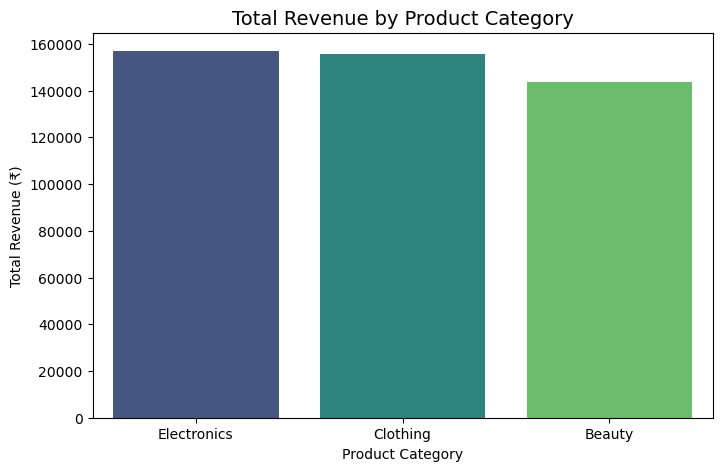

In [2]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values, palette='viridis')
plt.title('Total Revenue by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Revenue (₹)')
plt.show()

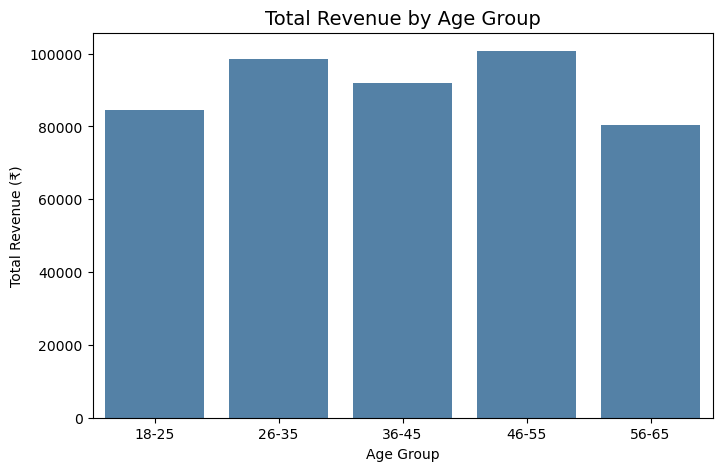

In [3]:
df['Age Group'] = pd.cut(df['Age'], bins=[17, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
age_revenue = df.groupby('Age Group', observed=True)['Total Amount'].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=age_revenue.index, y=age_revenue.values, color='steelblue')
plt.title('Total Revenue by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Total Revenue (₹)')
plt.show()

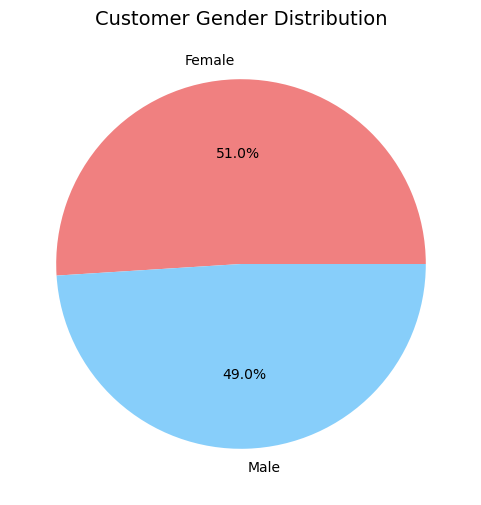

In [4]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title('Customer Gender Distribution', fontsize=14)
plt.show()

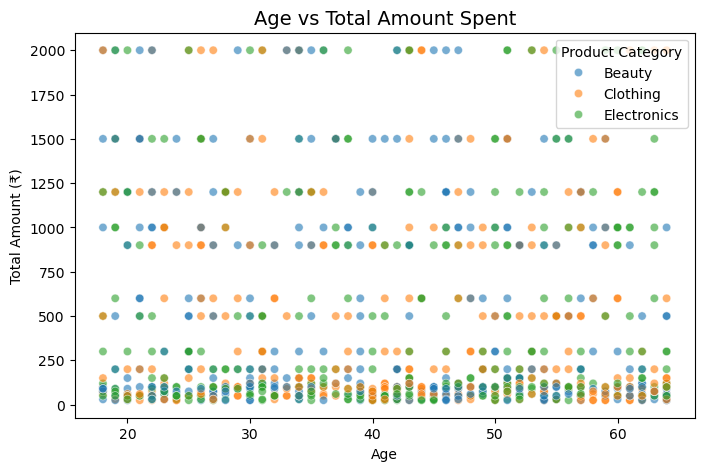

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Total Amount', data=df, hue='Product Category', alpha=0.6)
plt.title('Age vs Total Amount Spent', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Total Amount (₹)')
plt.show()

C:\Users\surys\AppData\Local\Temp\ipykernel_5840\359914775.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Product Category', y='Total Amount', data=df, palette='Set2')


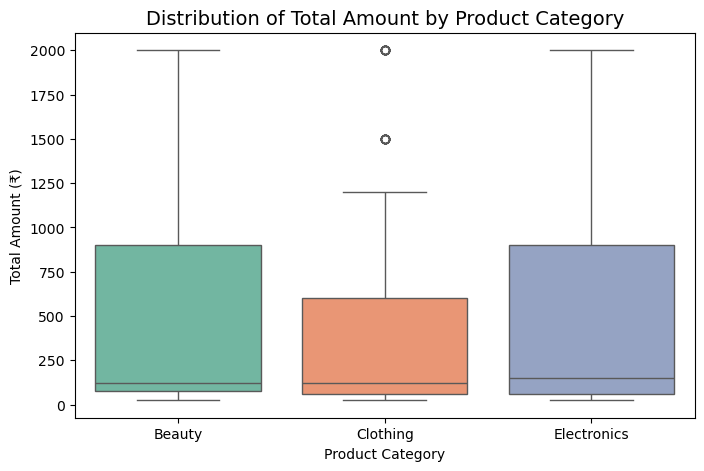

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Product Category', y='Total Amount', data=df, palette='Set2')
plt.title('Distribution of Total Amount by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Total Amount (₹)')
plt.show()

## Data Visualization Findings — Retail Sales Dataset

**Charts created:**
1. **Bar chart** — Total revenue by product category (Electronics highest, Beauty lowest)
2. **Bar chart** — Total revenue by age group (46-55 age group leads)
3. **Pie chart** — Gender distribution (51% Female, 49% Male — balanced)
4. **Scatter plot** — Age vs Total Amount, colored by category (no strong age-spending correlation for individual purchases)
5. **Boxplot** — Distribution of Total Amount by category (confirms spending is spread out, not tightly clustered, across all categories)

**Key takeaway:** While total *revenue* varies meaningfully by category and age group, *individual* transaction amounts don't show strong patterns tied to age — spending behavior is broadly similar across demographics, but aggregated at scale, certain groups (like 46-55 year-olds) and categories (like Electronics) contribute disproportionately more to overall revenue.